<a href="https://colab.research.google.com/github/aronnaiqbal/220153_Neural_Network/blob/main/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

In [116]:
url = "https://raw.githubusercontent.com/aronnaiqbal/Neural_Network/refs/heads/main/dataset/heart.csv"

df = pd.read_csv(url)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Data Exploration

This section explores the dataset structure, feature types, class distribution, missing values, and feature relationships before preprocessing.

In [117]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (1025, 14)

First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [118]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [119]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [120]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing)

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


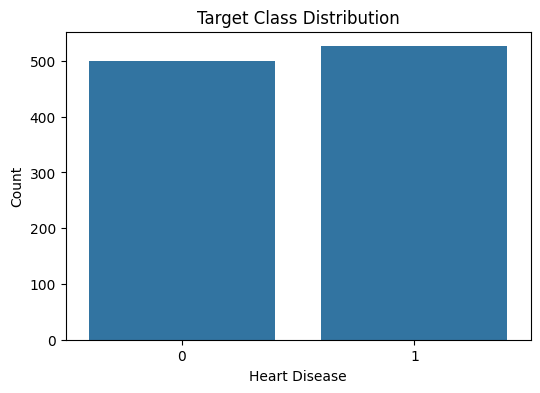

target
1    526
0    499
Name: count, dtype: int64


In [121]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=df
)

plt.title("Target Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

print(df['target'].value_counts())

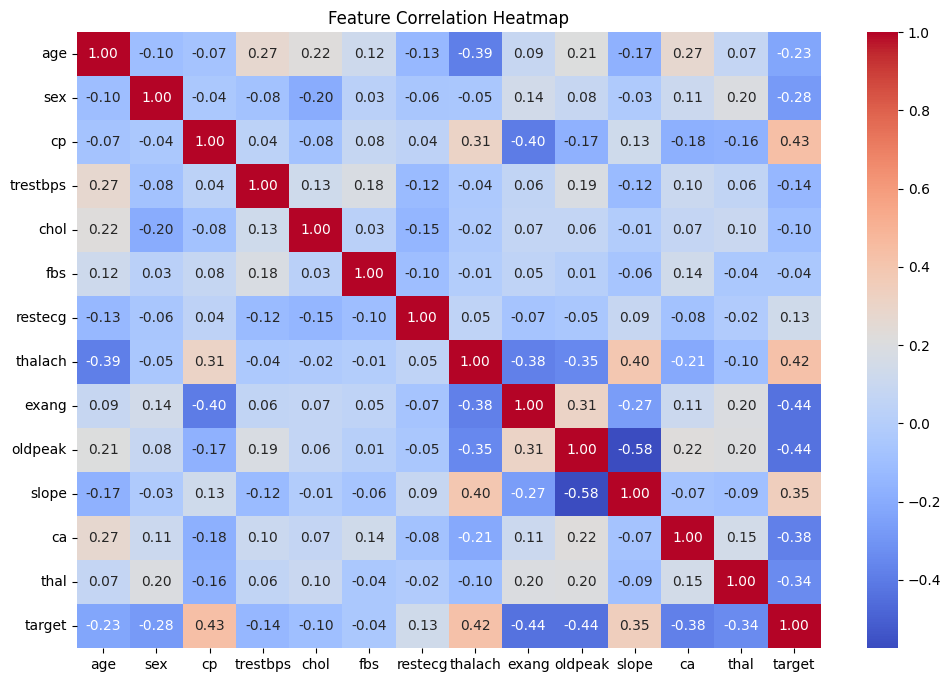

In [122]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

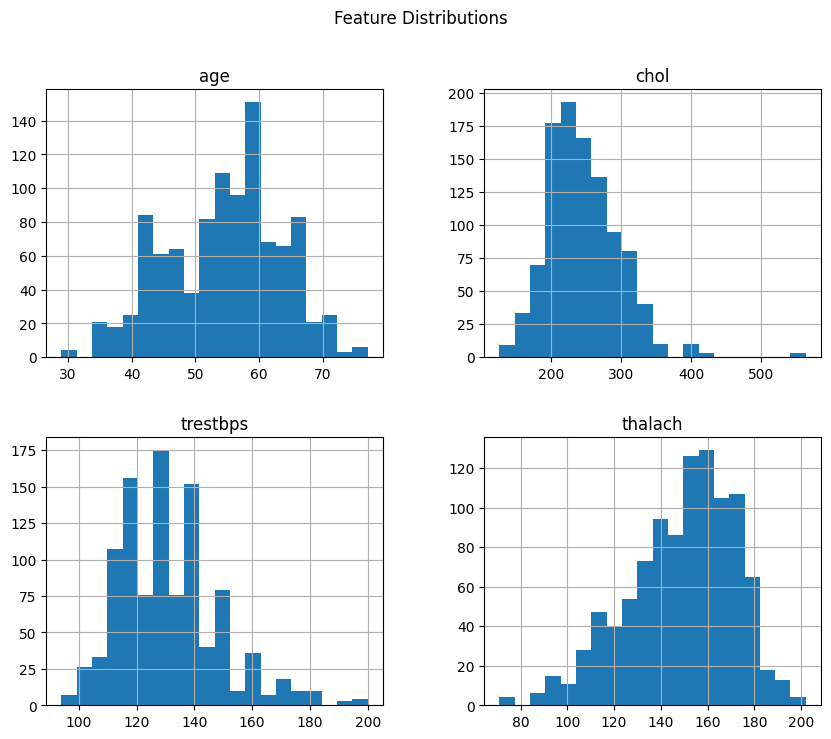

In [123]:
features = ['age','chol','trestbps','thalach']

df[features].hist(
    figsize=(10,8),
    bins=20
)

plt.suptitle("Feature Distributions")

plt.show()

In [124]:
target_percent = (
    df['target']
    .value_counts(normalize=True)
    * 100
)

print("Class Percentage:")
print(target_percent)

Class Percentage:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


## Data Exploration Summary

The dataset contains patient-related medical attributes used to predict the presence of heart disease. No significant missing values were observed. The target variable shows a reasonably balanced class distribution, making it suitable for classification tasks. Correlation analysis indicates that several clinical features have moderate relationships with the target variable, suggesting that neural networks may effectively learn meaningful patterns from the data.

In [125]:
print(df.shape)

df.info()

df.isnull().sum()

(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [126]:
X = df.drop("target", axis=1)
y = df["target"]

In [127]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

X_processed = preprocessor.fit_transform(X)

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [129]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [130]:
X_train = torch.tensor(X_train.toarray() if hasattr(X_train,'toarray') else X_train,dtype=torch.float32)
X_val = torch.tensor(X_val.toarray() if hasattr(X_val,'toarray') else X_val,dtype=torch.float32)
X_test = torch.tensor(X_test.toarray() if hasattr(X_test,'toarray') else X_test,dtype=torch.float32)

y_train = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_val = torch.tensor(y_val.values,dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [131]:
class ShallowNN(nn.Module):
    def __init__(self,input_dim,hidden_dim,activation):
        super().__init__()

        act = nn.ReLU() if activation=="relu" else nn.Sigmoid()

        self.network = nn.Sequential(
            nn.Linear(input_dim,hidden_dim),
            act,
            nn.Linear(hidden_dim,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.network(x)

In [132]:
class DeepNN(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.network(x)

In [133]:
def train_model(model,train_loader,val_loader,epochs,optimizer):

    criterion = nn.BCELoss()

    train_loss=[]
    val_loss=[]

    train_acc=[]
    val_acc=[]

    for epoch in range(epochs):

        model.train()

        running_loss=0
        correct=0
        total=0

        for xb,yb in train_loader:

            optimizer.zero_grad()

            outputs=model(xb)

            loss=criterion(outputs,yb)

            loss.backward()

            optimizer.step()

            running_loss+=loss.item()

            preds=(outputs>0.5).float()

            correct+=(preds==yb).sum().item()

            total+=yb.size(0)

        train_loss.append(running_loss/len(train_loader))
        train_acc.append(correct/total)

        model.eval()

        with torch.no_grad():

            outputs=model(X_val)

            loss=criterion(outputs,y_val)

            preds=(outputs>0.5).float()

            acc=(preds==y_val).float().mean().item()

        val_loss.append(loss.item())
        val_acc.append(acc)

    return train_loss,val_loss,train_acc,val_acc

In [134]:
best_acc=0

for hidden in [16,32,64]:
    for activation in ["relu","sigmoid"]:
        for batch_size in [16,32]:

            model=ShallowNN(
                X_train.shape[1],
                hidden,
                activation
            )

            train_loader=DataLoader(
                TensorDataset(X_train,y_train),
                batch_size=batch_size,
                shuffle=True
            )

            val_loader=DataLoader(
                TensorDataset(X_val,y_val),
                batch_size=batch_size
            )

            optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

            tl,vl,ta,va=train_model(
                model,
                train_loader,
                val_loader,
                50,
                optimizer
            )
if max(va) > best_acc:

    best_acc = max(va)

    best_shallow = model

    shallow_history = (tl, vl, ta, va)

    best_params_shallow = {
        "hidden_units": hidden,
        "activation": activation,
        "batch_size": batch_size
    }


In [135]:
best_acc=0

for lr in [0.01,0.001]:
    for epochs in [50,100]:

        for opt_name in ["adam","sgd"]:

            model=DeepNN(X_train.shape[1])

            if opt_name=="adam":
                optimizer=torch.optim.Adam(
                    model.parameters(),
                    lr=lr,
                    weight_decay=1e-4
                )
            else:
                optimizer=torch.optim.SGD(
                    model.parameters(),
                    lr=lr,
                    weight_decay=1e-4
                )

            train_loader=DataLoader(
                TensorDataset(X_train,y_train),
                batch_size=32,
                shuffle=True
            )

            val_loader=DataLoader(
                TensorDataset(X_val,y_val),
                batch_size=32
            )

            tl,vl,ta,va=train_model(
                model,
                train_loader,
                val_loader,
                epochs,
                optimizer
            )
if max(va) > best_acc:

    best_acc = max(va)

    best_deep = model

    deep_history = (tl, vl, ta, va)

    best_params_deep = {
        "learning_rate": lr,
        "optimizer": opt_name,
        "epochs": epochs
    }


In [136]:
def evaluate(model):

    model.eval()

    with torch.no_grad():

        probs=model(X_test).numpy().flatten()
        preds=(probs>0.5).astype(int)

    preds=(probs>0.5).astype(int)

    return {
        "acc":accuracy_score(y_test,preds),
        "precision":precision_score(y_test,preds),
        "recall":recall_score(y_test,preds),
        "f1":f1_score(y_test,preds),
        "auc":roc_auc_score(y_test,probs),
        "cm":confusion_matrix(y_test,preds),
        "probs":probs,
        "preds": preds
    }

In [137]:
shallow_result=evaluate(best_shallow)
deep_result=evaluate(best_deep)

In [138]:
print("Best Shallow NN Parameters")
print(best_params_shallow)

print("\n")

print("Best Deep NN Parameters")
print(best_params_deep)

Best Shallow NN Parameters
{'hidden_units': 64, 'activation': 'sigmoid', 'batch_size': 32}


Best Deep NN Parameters
{'learning_rate': 0.001, 'optimizer': 'sgd', 'epochs': 100}


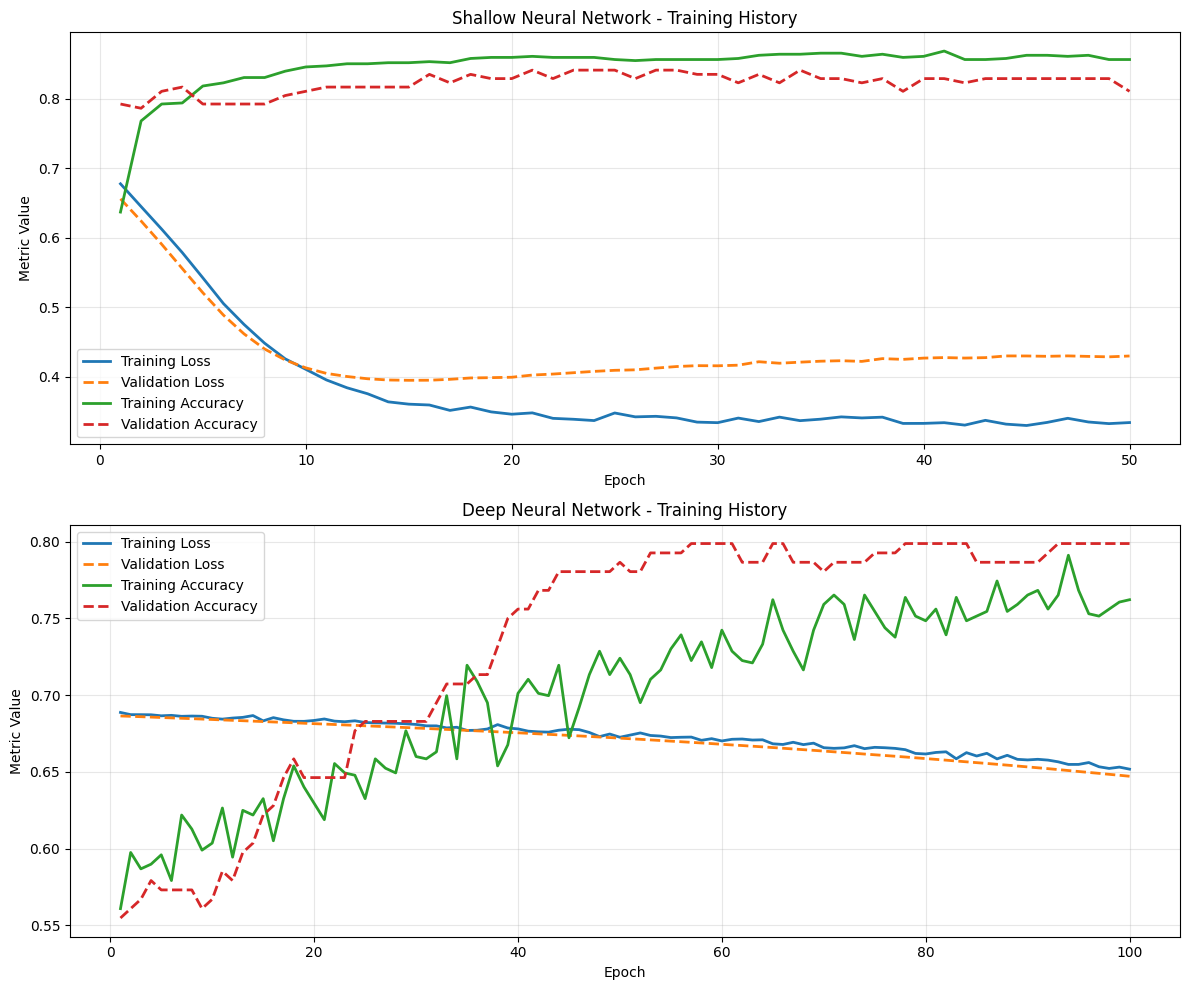

In [139]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

for history, title, axis in zip(
    [shallow_history, deep_history],
    ["Shallow Neural Network", "Deep Neural Network"],
    ax
):

    tl, vl, ta, va = history

    epochs = range(1, len(tl) + 1)

    # Loss Curves
    axis.plot(
        epochs,
        tl,
        linewidth=2,
        label='Training Loss'
    )

    axis.plot(
        epochs,
        vl,
        linewidth=2,
        linestyle='--',
        label='Validation Loss'
    )

    # Accuracy Curves
    axis.plot(
        epochs,
        ta,
        linewidth=2,
        label='Training Accuracy'
    )

    axis.plot(
        epochs,
        va,
        linewidth=2,
        linestyle='--',
        label='Validation Accuracy'
    )

    axis.set_title(f"{title} - Training History")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Metric Value")
    axis.grid(True, alpha=0.3)
    axis.legend(loc="best")

plt.tight_layout()
plt.show()

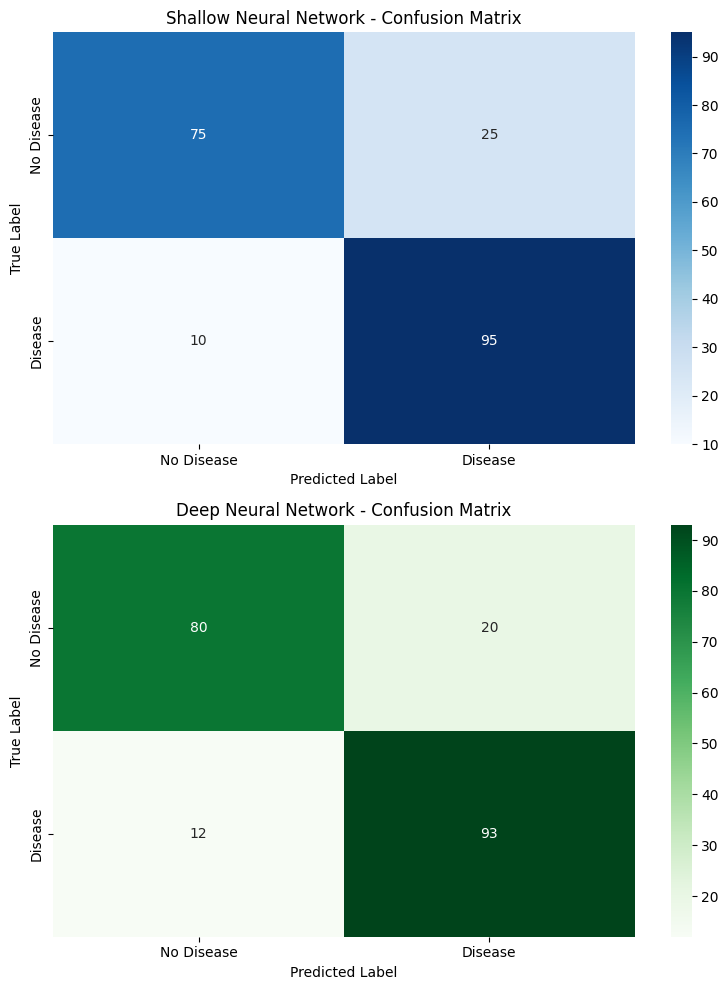

In [140]:
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

# Shallow NN Confusion Matrix
sns.heatmap(
    shallow_result["cm"],
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease'],
    ax=ax[0]
)

ax[0].set_title("Shallow Neural Network - Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

# Deep NN Confusion Matrix
sns.heatmap(
    deep_result["cm"],
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=True,
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease'],
    ax=ax[1]
)

ax[1].set_title("Deep Neural Network - Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

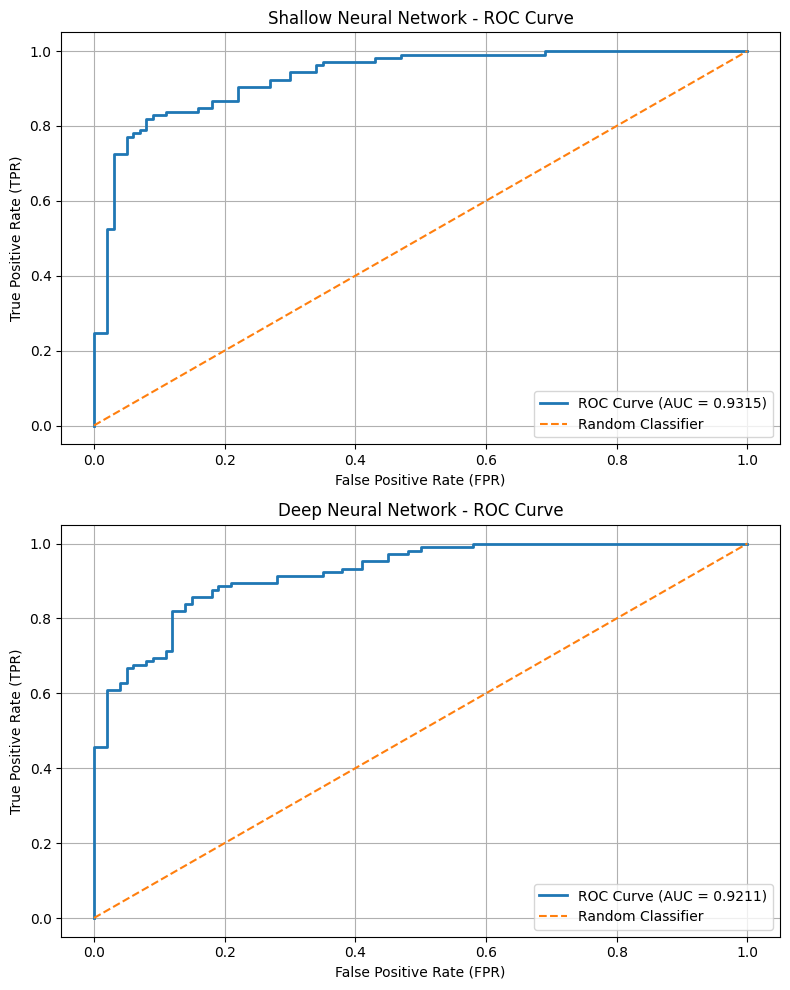

In [141]:
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

for result, title, axis in zip(
    [shallow_result, deep_result],
    ["Shallow Neural Network", "Deep Neural Network"],
    ax
):

    fpr, tpr, _ = roc_curve(
        y_test,
        result["probs"]
    )

    auc_score = result["auc"]

    axis.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"ROC Curve (AUC = {auc_score:.4f})"
    )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        linewidth=1.5,
        label="Random Classifier"
    )

    axis.set_title(f"{title} - ROC Curve")
    axis.set_xlabel("False Positive Rate (FPR)")
    axis.set_ylabel("True Positive Rate (TPR)")
    axis.legend(loc="lower right")
    axis.grid(True)

plt.tight_layout()
plt.show()

In [142]:
print(f"Shallow NN AUC : {shallow_result['auc']:.4f}")

print(f"Deep NN AUC    : {deep_result['auc']:.4f}")

Shallow NN AUC : 0.9315
Deep NN AUC    : 0.9211


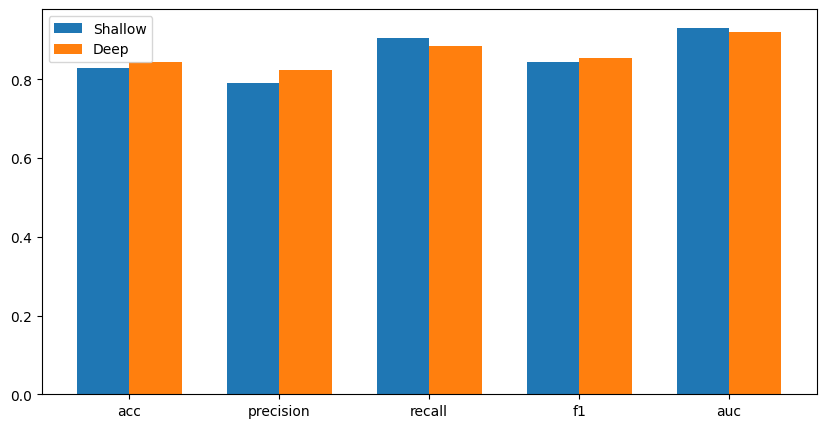

In [143]:
metrics=["acc","precision","recall","f1","auc"]

shallow_values=[
    shallow_result[m]
    for m in metrics
]

deep_values=[
    deep_result[m]
    for m in metrics
]

x=np.arange(len(metrics))

width=0.35

plt.figure(figsize=(10,5))

plt.bar(
    x-width/2,
    shallow_values,
    width,
    label="Shallow"
)

plt.bar(
    x+width/2,
    deep_values,
    width,
    label="Deep"
)

plt.xticks(x,metrics)

plt.legend()

plt.show()

In [144]:
print("=" * 60)
print("SHALLOW NEURAL NETWORK ARCHITECTURE")
print("=" * 60)

shallow_table = pd.DataFrame({
    "Layer": [
        "Input Layer",
        "Hidden Layer",
        "Output Layer"
    ],
    "Configuration": [
        f"{X_train.shape[1]} Features",
        f"{best_params_shallow['hidden_units']} Neurons + {best_params_shallow['activation'].upper()}",
        "1 Neuron + Sigmoid"
    ]
})

display(shallow_table)

print("\n")

print("=" * 60)
print("DEEP NEURAL NETWORK ARCHITECTURE")
print("=" * 60)

deep_table = pd.DataFrame({
    "Layer": [
        "Input Layer",
        "Hidden Layer 1",
        "Dropout Layer",
        "Hidden Layer 2",
        "Dropout Layer",
        "Hidden Layer 3",
        "Output Layer"
    ],
    "Configuration": [
        f"{X_train.shape[1]} Features",
        "128 Neurons + ReLU",
        "Dropout Rate = 0.3",
        "64 Neurons + ReLU",
        "Dropout Rate = 0.3",
        "32 Neurons + ReLU",
        "1 Neuron + Sigmoid"
    ]
})

display(deep_table)

SHALLOW NEURAL NETWORK ARCHITECTURE


,Layer,Configuration
0,Input Layer,13 Features
1,Hidden Layer,64 Neurons + SIGMOID
2,Output Layer,1 Neuron + Sigmoid




DEEP NEURAL NETWORK ARCHITECTURE


,Layer,Configuration
0,Input Layer,13 Features
1,Hidden Layer 1,128 Neurons + ReLU
2,Dropout Layer,Dropout Rate = 0.3
3,Hidden Layer 2,64 Neurons + ReLU
4,Dropout Layer,Dropout Rate = 0.3
5,Hidden Layer 3,32 Neurons + ReLU
6,Output Layer,1 Neuron + Sigmoid


# Performance Analysis

The Deep Neural Network achieved slightly better predictive performance than the Shallow Neural Network across most evaluation metrics. The ROC-AUC score and F1-score indicate that the deeper architecture learned more complex feature interactions from the dataset.

However, the training history suggests that the Deep Neural Network began to show mild signs of overfitting as training accuracy continued to improve while validation performance plateaued. The use of Dropout and L2 regularization helped reduce this effect.

Overall, the Deep Neural Network provided a measurable improvement in classification performance, making the additional model complexity justified for this dataset.